In [1]:
%matplotlib widget
import jax
import jax.numpy as jnp
from dataclasses import dataclass
from jax.tree_util import register_dataclass
import scipy.optimize as scio
import matplotlib.pyplot as plt 
from matplotlib import ticker
from results import frequency_list, resistance_list, power_list
import plotly.graph_objects as go

jax.config.update("jax_enable_x64", True) 
jax.config.update("jax_debug_nans", True)
cmap = 'jet'

Empty DataFrame
Columns: [__header__, __version__, __globals__, Rload, acc_amp, acc_meas_vect, dep_meas_vect, f, sweep_up, tension_meas_vect, time_meas, vit_meas_vect, power, v_rms, x_rms, dotx_rms, ddotx_rms]
Index: []
(1500, 17)


In [2]:
# class SystemParams:
@register_dataclass  # rend la classe jax-compatible
@dataclass
class SystemParams:
    gamma: float = (0.1,)
    w: float = (100 * 2 * jnp.pi,)
    R: float = (10e3,)


w0 = 25.09 * 2 * jnp.pi
Cp = 2.1569e-8
km2 = 6.0893e-2
Q = 103.06
M = 0.1
ProtoCaracsRef = jnp.array([w0, Cp, km2, Q, M])

In [3]:
# Fonction qui calcule la puissance


def system_signals(params: SystemParams, vect):
    """
    returns x1, x2, phi_x1, phi_x2, v1, v2, P1in, P2in
    position resonator 1, voltage resonator 1
    position resonator 2, voltage resonator 2
    computed by analytical analysis
    for the two couples linear resonators system
    """

    gamma = params.gamma
    w = params.w
    R = params.R

    w0 = vect[0]
    Cp = vect[1]
    km2 = vect[2]
    Q = vect[3]
    M = vect[4]

    alpha = jnp.sqrt(km2 * M * w0**2 * Cp)
    a = -(w**2) + 1.0j * w * w0 / Q + w0**2
    b = alpha / M
    c = 1.0j * w * alpha
    d = 1.0j * w * Cp + 1 / R

    v = c * gamma / (b * c + d * a)

    P = jnp.abs(v) ** 2 / (2 * R)

    return w, R, P

In [4]:
# Récupère les listes de fréquences et de résistances et jnp array

frequency_list = jnp.asarray(frequency_list)
resistance_list = jnp.asarray(resistance_list)
power_exp = jnp.asarray(power_list)
power_exp.shape

(30, 50)

In [5]:
# Calcul de la puissance en vmap sur omega et R

vpower = jax.vmap(
    jax.vmap(
        system_signals,
        in_axes=(
            SystemParams(
                gamma=None,
                w=0,
                R=None,
            ),
            None,
        ),
    ),
    in_axes=(
        SystemParams(
            gamma=None,
            w=None,
            R=0,
        ),
        None,
    ),
)


def power(vect):
    params_w = SystemParams(
        gamma=0.1,
        w=frequency_list * 2 * jnp.pi,
        R=resistance_list,
    )

    return vpower(params_w, vect)

In [6]:
def error_function(X0):
    caracs = X0 * ProtoCaracsRef
    w, r, power_sim = power(caracs)
    return (power_sim - power_exp).flatten()
    # vector_r = abs(Y1 - jnp.asarray(power_exp))
    # norm_r = jnp.linalg.norm(vector_r.reshape(30 * 50))
    # return norm_r

In [7]:
ProtoCaracsRef

Array([1.57645119e+02, 2.15690000e-08, 6.08930000e-02, 1.03060000e+02,
       1.00000000e-01], dtype=float64)

In [8]:
x0 = jnp.ones_like(ProtoCaracsRef)
# res = scio.minimize(
#     error_function, x0, method="nelder-mead", options={"xatol": 1e-8, "disp": True}
# )
res = scio.least_squares(error_function, x0)
xf = res.x
ProtoCaracsOpt = xf * ProtoCaracsRef

print(
    "w0 = {}, \nCp = {}, \nkm2 = {}, \nQ = {}, \nM = {}".format(
        ProtoCaracsOpt[0] / (2 * jnp.pi), ProtoCaracsOpt[1], ProtoCaracsOpt[2], ProtoCaracsOpt[3], ProtoCaracsOpt[4]
    )
)

w0 = 25.019192789677543, 
Cp = 2.6370231328848966e-08, 
km2 = 0.04819477406157226, 
Q = 75.91568180927055, 
M = 0.08656027181786959


In [9]:
w_grid, R_grid, power_th = power(ProtoCaracsOpt)
f_grid = w_grid / (2. * jnp.pi)

/tmp/ipykernel_641584/244127212.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


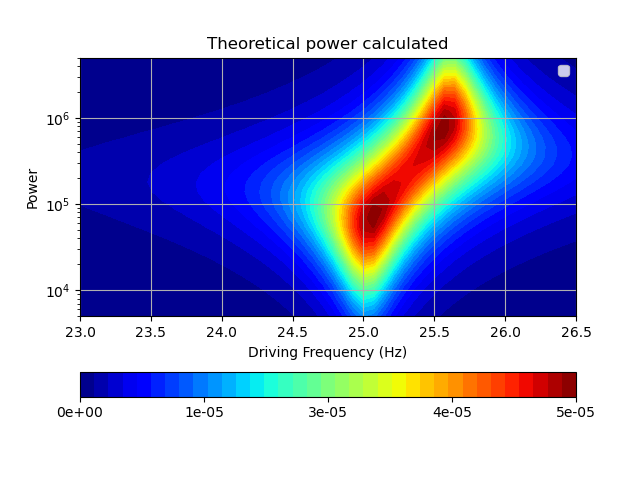

In [10]:
plt.figure()
plt.contourf(f_grid, R_grid, power_th, 50, cmap=cmap)
locator = ticker.LinearLocator(numticks=5)
cbar = plt.colorbar(orientation="horizontal", format="%.e", ticks=locator)
plt.xlabel("Driving Frequency (Hz)")
plt.ylabel("Power")
plt.title("Theoretical power calculated")
plt.legend()
plt.yscale("log")
plt.grid()
plt.show()

In [11]:
power_exp.shape
f_grid.shape

(30, 50)

In [12]:
fig = go.Figure(data=[
    go.Surface(x=f_grid, y=jnp.log10(R_grid), z=power_exp*1.e6, opacity=0.5),
    go.Surface(x=f_grid, y=jnp.log10(R_grid), z=power_th*1.e6, opacity = .5, showscale=False, colorscale="jet"),

])

def update(fig):
    fig.update_layout(scene = dict(
                      xaxis=dict(
                          title=dict(
                              text='Frequency, f [Hz]'
                          )
                      ),
                      yaxis=dict(
                          title=dict(
                              text='Resistance, R [log10(Ohm)]'
                          )
                      ),
                      zaxis=dict(
                          title=dict(
                              text='Power [muW]'
                          )
                      ),
                    ),
                    width=700,
                    margin=dict(r=20, b=10, l=10, t=10))
update(fig)
fig.show()

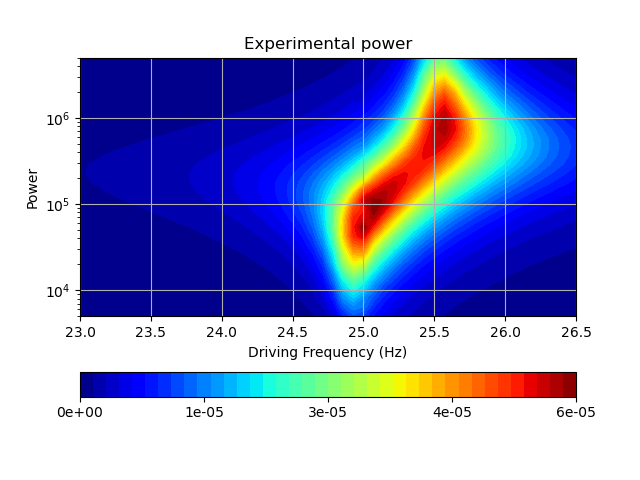

In [13]:
plt.figure()
plt.contourf(frequency_list, resistance_list, power_exp, 50, cmap=cmap)
locator = ticker.LinearLocator(numticks=5)
cbar = plt.colorbar(orientation="horizontal", format="%.e", ticks=locator)
plt.xlabel("Driving Frequency (Hz)")
plt.ylabel("Power")
plt.title("Experimental power")
#plt.legend()
plt.yscale("log")
plt.grid()
plt.show()

In [14]:
fig = go.Figure(data=[
    go.Surface(x=f_grid, y=jnp.log10(R_grid), z=(power_th - power_exp)*1.e6, opacity=0.5, colorscale="jet"),

])

def update(fig):
    fig.update_layout(scene = dict(
                      xaxis=dict(
                          title=dict(
                              text='Frequency, f [Hz]'
                          )
                      ),
                      yaxis=dict(
                          title=dict(
                              text='Resistance, R [log10(Ohm)]'
                          )
                      ),
                      zaxis=dict(
                          title=dict(
                              text='Power [muW]'
                          )
                      ),
                    ),
                    width=700,
                    margin=dict(r=20, b=10, l=10, t=10))
update(fig)
fig.show()

/tmp/ipykernel_641584/3930962745.py:14: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



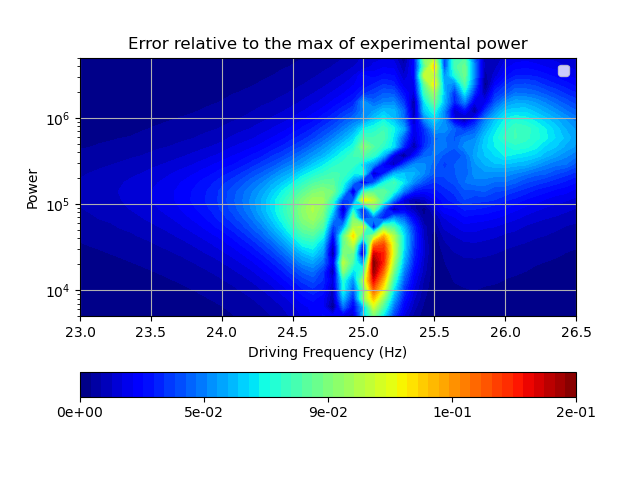

In [15]:
plt.figure()
plt.contourf(
    frequency_list,
    resistance_list,
    abs(power_exp - power_th) / (power_exp.max(axis=1).max(axis=0)),
    50,
    cmap=cmap,
)
locator = ticker.LinearLocator(numticks=5)
cbar = plt.colorbar(orientation="horizontal", format="%.e", ticks=locator)
plt.xlabel("Driving Frequency (Hz)")
plt.ylabel("Power")
plt.title("Error relative to the max of experimental power")
plt.legend()
plt.yscale("log")
plt.grid()
plt.show()

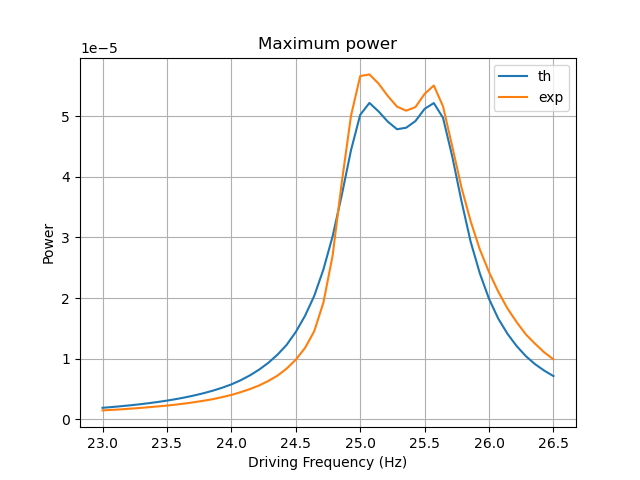

In [16]:
plt.figure()
plt.plot(frequency_list, power_th.max(axis=0), label="th")
plt.plot(frequency_list, power_exp.max(axis=0), label="exp")
plt.xlabel("Driving Frequency (Hz)")
plt.ylabel("Power")
plt.title("Maximum power")
plt.legend()
plt.grid()
plt.show()